In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import scipy

In [2]:
def calc_corr(x, y, return_p = False):
    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y, nan_policy = 'omit')
    
    if(return_p):
        return p_value, r_value**2
    else:
        return r_value**2

Initial climate inidices analysis

In [3]:
#Import and concat data
clim_files = glob('./data/processed/*.csv')

clim_dat = pd.DataFrame()
for file in clim_files:
    temp = pd.read_csv(file)
    clim_dat = pd.concat([clim_dat, temp])

#reshape data
clim_dat_wide = clim_dat.pivot(index = ['site', 'doy', 'lat', 'lon'], columns = ['variable']).reset_index()
clim_dat_wide.columns = ['_'.join(map(str, col)).strip('_') for col in clim_dat_wide.columns.values]

In [4]:
clim_dat_wide

,site,doy,lat,lon,value_maxTemp,value_minTemp,value_precip_cum
0,ASH,2.0,46.050133,-95.878490,30.585873,18.656400,0.031316
1,ASH,3.0,46.050133,-95.878490,29.292963,14.063779,0.053208
2,ASH,4.0,46.050133,-95.878490,25.041018,1.567986,0.062196
3,ASH,5.0,46.050133,-95.878490,31.924119,5.214187,0.069543
4,ASH,6.0,46.050133,-95.878490,31.159680,9.308063,0.070269
...,...,...,...,...,...,...,...
2185,SMI,362.0,44.418970,-92.942041,25.127230,8.409525,34.403769
2186,SMI,363.0,44.418970,-92.942041,27.745051,10.533721,34.362841
2187,SMI,364.0,44.418970,-92.942041,26.212449,3.350109,34.897001
2188,SMI,365.0,44.418970,-92.942041,27.837303,8.620492,36.458291


In [5]:
#Conversions 
#farenheit to C
clim_dat_wide['value_maxTemp_C'] = 5/9*(clim_dat_wide['value_maxTemp'] - 32)
clim_dat_wide['value_minTemp_C'] = 5/9*(clim_dat_wide['value_minTemp'] - 32)
clim_dat_wide['value_meanTemp_C'] = 0.5*(clim_dat_wide['value_maxTemp_C'] + clim_dat_wide['value_minTemp_C'])

#precip in to cm
clim_dat_wide['value_precip_cm'] = 2.54*(clim_dat_wide['value_precip_cum'])


In [6]:
clim_dat_wide.head()

,site,doy,lat,lon,value_maxTemp,value_minTemp,value_precip_cum,value_maxTemp_C,value_minTemp_C,value_meanTemp_C,value_precip_cm
0,ASH,2.0,46.050133,-95.87849,30.585873,18.656400,0.031316,-0.785626,-7.413111,-4.099369,0.079543
1,ASH,3.0,46.050133,-95.87849,29.292963,14.063779,0.053208,-1.503910,-9.964567,-5.734238,0.135148
2,ASH,4.0,46.050133,-95.87849,25.041018,1.567986,0.062196,-3.866101,-16.906675,-10.386388,0.157979
3,ASH,5.0,46.050133,-95.87849,31.924119,5.214187,0.069543,-0.042156,-14.881007,-7.461582,0.176639
4,ASH,6.0,46.050133,-95.87849,31.159680,9.308063,0.070269,-0.466844,-12.606632,-6.536738,0.178482


In [7]:
#calculations
start_date = 121 #may 1st

#heat indices
gdd_thresh = 10 #degrees C, growing degrees
hdd_thresh = 18 #degrees C, heating degrees
sdd_thresh = 30 #degrees C, stress degrees

# NOTE see if Kate or Matt have information on the relationship between temperature and growth rate -- we could use this to set 
# multiple thresholds to distinguish between optimal growth and stress periods for the plant
# REFS: file:///C:/Users/marie/Downloads/renate,+Journal+editor,+ms+9741+Greer.pdf
#       https://mrcc.purdue.edu/VIP/aboutSDD

#growing degree days
clim_dat_wide['index_GDD'] = (clim_dat_wide['value_meanTemp_C'] - gdd_thresh).clip(lower = 0)
#heating degree days
clim_dat_wide['index_HDD'] = (clim_dat_wide['value_meanTemp_C'] - hdd_thresh).clip(lower = 0)
#stress degree days
clim_dat_wide['index_SDD'] = (clim_dat_wide['value_meanTemp_C'] - sdd_thresh).clip(lower = 0)

#accumulate over year
clim_dat_wide[['index_GDD_cum', 'index_HDD_cum', 'index_SDD_cum']] = clim_dat_wide.groupby([
    'site', 'lat', 'lon'])[['index_GDD', 'index_HDD', 'index_SDD']].cumsum()

#trim to start date of season - used to subtract from season accumulations
#NOTE MWJ: 5/27/26 - removed the slicing according to the first day of may
'''
base_values = (
    clim_dat_wide[clim_dat_wide['doy'] == start_date-1]
    .groupby(['site', 'lat', 'lon'])[['value_precip_cm', 'index_GDD_cum', 'index_HDD_cum', 'index_SDD_cum']]
    .first()  # take first in case of duplicates
)

base_values = base_values.rename(columns = {'value_precip_cm':'base_value_precip_cm', 
                                            'index_GDD_cum':'base_index_GDD_cum', 
                                            'index_HDD_cum':'base_index_HDD_cum', 
                                            'index_SDD_cum':'base_index_SDD_cum',
})

#subtract initial value from cumulative summations
clim_dat_season = pd.merge(clim_dat_wide, base_values, on = ['site', 'lat', 'lon'])[clim_dat_wide.doy >= start_date].reset_index(drop = True)
clim_dat_season['value_precip_cm'] = clim_dat_season.value_precip_cm - clim_dat_season.base_value_precip_cm
clim_dat_season['index_GDD_cum'] = clim_dat_season.index_GDD_cum - clim_dat_season.base_index_GDD_cum
clim_dat_season['index_HDD_cum'] = clim_dat_season.index_HDD_cum - clim_dat_season.base_index_HDD_cum
clim_dat_season['index_SDD_cum'] = clim_dat_season.index_SDD_cum - clim_dat_season.base_index_SDD_cum

#drop unecessary columns
clim_dat_season = clim_dat_wide.drop(columns = ['value_minTemp_F','value_maxTemp_F',
       'value_precip_cum', 'base_value_precip_cm',
       'base_index_GDD_cum', 'base_index_HDD_cum', 
       'base_index_SDD_cum'])
'''

#Add in diurnal fluctuations
clim_dat_wide['index_diurnalTemp_C'] = (clim_dat_wide.value_maxTemp_C - clim_dat_wide.value_minTemp_C).clip(0)

#drop unecessary columns and the Bismark sites (no 2020 data)
clim_dat_final_2020 = clim_dat_wide[clim_dat_wide.site != 'BIS'].drop(columns = ['value_minTemp','value_maxTemp',
       'value_precip_cum', 
       'index_GDD', 'index_HDD', 
       'index_SDD'])

In [8]:
#export - ready to merge with sensory panel data for analysis
clim_dat_final_2020.to_csv('./data/allSites_climate_indices_2020.csv', index = False)

In [9]:
#Import 2019 climate indices and add together
clim_dat_final_2019 = pd.read_csv('./data/allSites_climate_indices_2019.csv')

#concat
clim_dat_final_2020['Year'] = 2020
clim_dat_final_2019['Year'] = 2019
clim_dat_merged = pd.concat([clim_dat_final_2020, clim_dat_final_2019]).reset_index(drop = True)

clim_dat_merged

,site,doy,lat,lon,value_maxTemp_C,value_minTemp_C,value_meanTemp_C,value_precip_cm,index_GDD_cum,index_HDD_cum,index_SDD_cum,index_diurnalTemp_C,Year
0,ASH,2.0,46.050133,-95.878490,-0.785626,-7.413111,-4.099369,0.079543,0.00000,0.000000,0.000000,6.627485,2020
1,ASH,3.0,46.050133,-95.878490,-1.503910,-9.964567,-5.734238,0.135148,0.00000,0.000000,0.000000,8.460658,2020
2,ASH,4.0,46.050133,-95.878490,-3.866101,-16.906675,-10.386388,0.157979,0.00000,0.000000,0.000000,13.040574,2020
3,ASH,5.0,46.050133,-95.878490,-0.042156,-14.881007,-7.461582,0.176639,0.00000,0.000000,0.000000,14.838851,2020
4,ASH,6.0,46.050133,-95.878490,-0.466844,-12.606632,-6.536738,0.178482,0.00000,0.000000,0.000000,12.139787,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3640,SMI,361.0,44.418970,-92.942041,0.601395,-2.565858,-0.982232,133.891825,2132.01379,879.876331,11.315063,3.167253,2019
3641,SMI,362.0,44.418970,-92.942041,0.858024,-4.182035,-1.662006,133.754562,2132.01379,879.876331,11.315063,5.040059,2019
3642,SMI,363.0,44.418970,-92.942041,4.936268,-1.216374,1.859947,136.192629,2132.01379,879.876331,11.315063,6.152642,2019
3643,SMI,364.0,44.418970,-92.942041,8.664613,-0.838759,3.912927,137.335128,2132.01379,879.876331,11.315063,9.503371,2019


Text(0.5, 0, 'Day of the Year, May 1st - October 31st')

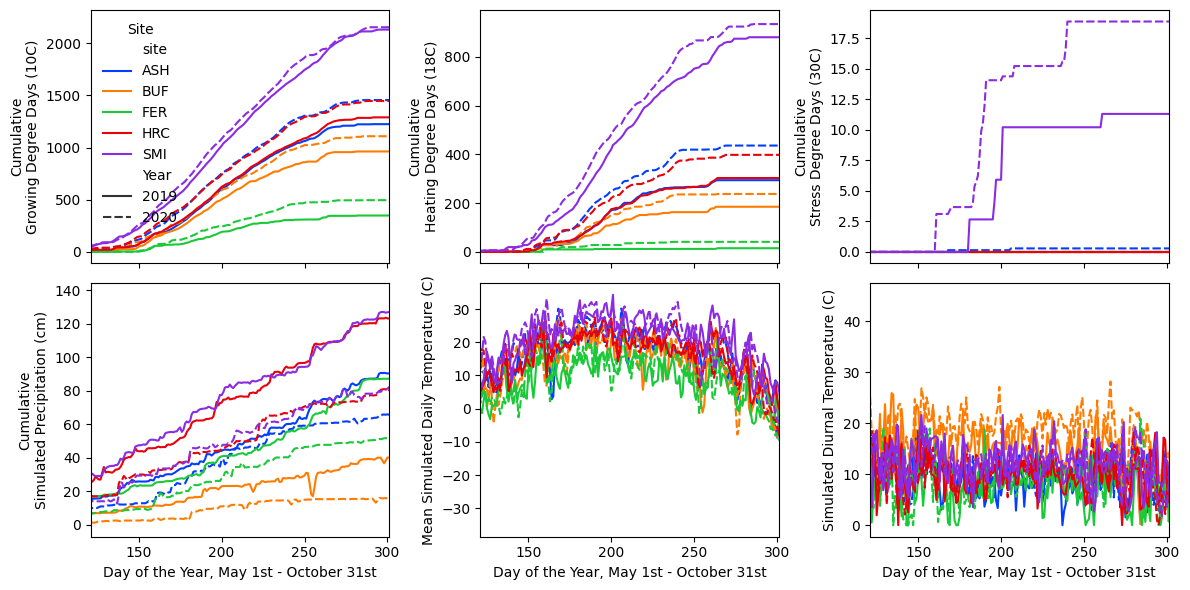

In [10]:
#Figures
fig, [[ax1, ax2, ax3], [ax4, ax5, ax6]] = plt.subplots(2, 3, figsize = (12, 6), 
                                    sharex=True, 
                                    layout = 'tight')

#GDD
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'index_GDD_cum', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax1)
ax1.set_ylabel('Cumulative\nGrowing Degree Days (10C)')
ax1.legend(title = 'Site', frameon = False)

#HDD
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'index_HDD_cum', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax2, legend = False)
ax2.set_ylabel('Cumulative\nHeating Degree Days (18C)')

#HDD
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'index_SDD_cum', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax3, legend = False)
ax3.set_ylabel('Cumulative\nStress Degree Days (30C)')

#Cumulative precip
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'value_precip_cm', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax4, legend = False)
ax4.set_ylabel('Cumulative\nSimulated Precipitation (cm)')

#Mean Temperature
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'value_meanTemp_C', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax5, legend = False)
ax5.set_ylabel('Mean Simulated Daily Temperature (C)')

#Diurnal Temperature
sns.lineplot(data = clim_dat_merged, x = 'doy', y = 'index_diurnalTemp_C', style = 'Year',
             hue = 'site', palette = 'bright',
             ax = ax6, legend = False)
ax6.set_ylabel('Simulated Diurnal Temperature (C)')

ax1.set_xlim(121, 301) #May1st to Oct31st
ax4.set_xlabel('Day of the Year, May 1st - October 31st')
ax5.set_xlabel('Day of the Year, May 1st - October 31st')
ax6.set_xlabel('Day of the Year, May 1st - October 31st')



Match with yield and BRIX measurements first

In [11]:
#read in data
yield_data_2019 = pd.read_csv('./data/2019_yield.csv', 
                         parse_dates = ['Harvestdate'])

yield_data_2020 = pd.read_csv('./data/2020_yield.csv', 
                         parse_dates = ['Harvestdate'])

#set doy for merging with climate data
yield_data_2019['doy'] = yield_data_2019.Harvestdate.dt.day_of_year
yield_data_2020['doy'] = yield_data_2020.Harvestdate.dt.day_of_year
yield_data_merged = pd.concat([yield_data_2019, yield_data_2020])

#merge
yield_clim_data = pd.merge(clim_dat_merged.drop(columns = ['value_maxTemp_C', 'value_minTemp_C', 'value_meanTemp_C', 'index_diurnalTemp_C']), yield_data_merged, on = ['doy', 'site'], how = 'inner')

yield_clim_data.head()

C:\Users\marie\AppData\Local\Temp\ipykernel_29808\1351103309.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_data_2020 = pd.read_csv('./data/2020_yield.csv',


,site,doy,lat,lon,value_precip_cm,index_GDD_cum,index_HDD_cum,index_SDD_cum,Year,Variety,Harvestdate,Avg_cluster,50_berry,Avg_berry,Brix,pH,TA,Label
0,ASH,255.0,46.050133,-95.87849,59.272932,1307.395100,419.267757,0.28702,2020,Marquette,2020-09-11,85.00,59.04,1.18,24.1,2.84,11.84,MQ-ASH-911
1,ASH,262.0,46.050133,-95.87849,60.579100,1343.806782,420.000939,0.28702,2020,Marquette,2020-09-18,87.00,66.38,1.33,24.5,2.91,11.62,MQ-ASH-918
2,ASH,266.0,46.050133,-95.87849,60.814403,1384.407414,429.259351,0.28702,2020,Brianna,2019-09-23,100.50,123.77,2.50,20.8,3.18,7.90,NaN
3,ASH,266.0,46.050133,-95.87849,60.814403,1384.407414,429.259351,0.28702,2020,Marquette,2019-09-23,90.00,64.23,1.29,25.2,2.82,12.67,MQ-ASH-923
4,ASH,269.0,46.050133,-95.87849,60.979677,1415.069559,435.921496,0.28702,2020,Marquette,2020-09-25,87.33,64.00,1.28,25.8,2.97,9.56,MQ-ASH-925


In [15]:
#Match with average temperature and average dirunal range for the season
site = []
doy = []
mT = []
mD = []
cultivar = []

for index,row in enumerate(yield_clim_data.itertuples(index=False)):
    temp = clim_dat_merged.where((clim_dat_merged.doy > start_date) & (clim_dat_merged.doy < yield_clim_data.doy[index]))
    meanTemp = np.nanmean(temp.value_meanTemp_C)
    meanDiurnal = np.nanmean(temp.index_diurnalTemp_C)

    #append
    site.append(yield_clim_data.site[index])
    doy.append(yield_clim_data.doy[index])
    mT.append(meanTemp)
    mD.append(meanDiurnal)
    cultivar.append(yield_clim_data.Variety[index])

#merge into datafram
meanVals = pd.DataFrame({
    'site':site, 
    'doy':doy,
    'value_meanTemp_C':mT,
    'value_meanDiurnal_C':mD, 
    'Variety' : cultivar})

In [20]:
#Merge mean values with other climate data
yield_clim_data_final = pd.merge(yield_clim_data, meanVals, on = ['site', 'doy', 'Variety'], how = 'inner').drop_duplicates()

In [21]:
yield_clim_data_final

,site,doy,lat,lon,value_precip_cm,index_GDD_cum,index_HDD_cum,index_SDD_cum,Year,Variety,Harvestdate,Avg_cluster,50_berry,Avg_berry,Brix,pH,TA,Label,value_meanTemp_C,value_meanDiurnal_C
0,ASH,255.0,46.050133,-95.878490,59.272932,1307.395100,419.267757,0.287020,2020,Marquette,2020-09-11,85.00,59.04,1.180,24.1,2.84,11.84,MQ-ASH-911,17.645335,11.579885
2,ASH,262.0,46.050133,-95.878490,60.579100,1343.806782,420.000939,0.287020,2020,Marquette,2020-09-18,87.00,66.38,1.330,24.5,2.91,11.62,MQ-ASH-918,17.538913,11.574970
4,ASH,266.0,46.050133,-95.878490,60.814403,1384.407414,429.259351,0.287020,2020,Brianna,2019-09-23,100.50,123.77,2.500,20.8,3.18,7.90,NaN,17.531698,11.609667
6,ASH,266.0,46.050133,-95.878490,60.814403,1384.407414,429.259351,0.287020,2020,Marquette,2019-09-23,90.00,64.23,1.290,25.2,2.82,12.67,MQ-ASH-923,17.531698,11.609667
8,ASH,269.0,46.050133,-95.878490,60.979677,1415.069559,435.921496,0.287020,2020,Marquette,2020-09-25,87.33,64.00,1.280,25.8,2.97,9.56,MQ-ASH-925,17.523421,11.646498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,SMI,259.0,44.418970,-92.942041,105.263866,1844.197909,779.604731,10.220010,2019,Marquette,2020-09-15,132.83,84.17,1.680,22.0,3.05,10.40,MQ-SMI-915,17.515236,11.572431
184,SMI,266.0,44.418970,-92.942041,108.851186,1967.363431,846.770252,11.315063,2019,LaCrescent,2019-09-23,82.00,77.41,1.550,20.0,3.05,16.07,NaN,17.531698,11.609667
186,SMI,266.0,44.418970,-92.942041,108.851186,1967.363431,846.770252,11.315063,2019,Marquette,2019-09-23,82.00,78.22,1.560,24.5,3.11,10.38,MQ-SMI-923,17.531698,11.609667
188,SMI,273.0,44.418970,-92.942041,110.721620,2040.082168,865.009832,11.315063,2019,LaCrescent,2019-09-30,90.17,76.89,1.538,21.0,2.96,12.45,NaN,17.409418,11.603785


Match with sensory panel analysis

In [24]:
#read in data
sensory_data = pd.read_csv('./data/tasting_eval.csv', 
                           na_values = ['-'])

#cleaning
#drop useless columns
sensory_data = sensory_data.drop(columns =
                ['First', 'Last', 'Rep.sample', 'Rep', 'Panelist', 'cal1', 'cal1.1', 'Site2', 'Weeka', 'WeekYear'])
sensory_data = sensory_data.rename(columns = {'Site':'site', 
                                              'Wine':'Label'})

#attempt merge
yield_clim_data_var = yield_clim_data_final[yield_clim_data_final.Variety == 'Marquette'].reset_index(drop = True)
all_data = pd.merge(yield_clim_data_var, sensory_data, on = ['site', 'Label', 'Year'], how = 'inner')

#esxport
all_data.to_csv('./data/all_merged_ClimHarvestTaste.csv', index = False)

In [27]:
all_data

,site,doy,lat,lon,value_precip_cm,index_GDD_cum,index_HDD_cum,index_SDD_cum,Year,Variety,...,Mushroom,Pepper,Cherry,Black_Currant,Jammy,Other,Pleasing,Like,Ripeness2,Notes
0,FER,262.0,47.56561,-96.135960,47.723438,479.813853,41.220250,0.000000,2020,Marquette,...,5.7,1.8,2.9,3.4,7.3,NaN,Unpleasant,No,Under Ripe,NaN
1,FER,262.0,47.56561,-96.135960,47.723438,479.813853,41.220250,0.000000,2020,Marquette,...,0.0,1.6,10.4,0.5,10.2,NaN,Pleasant,Yes,Ripe,Delicious!
2,FER,262.0,47.56561,-96.135960,47.723438,479.813853,41.220250,0.000000,2020,Marquette,...,5.2,4.8,5.2,4.0,6.0,NaN,Unpleasant,No,Under Ripe,NaN
3,FER,262.0,47.56561,-96.135960,47.723438,479.813853,41.220250,0.000000,2020,Marquette,...,0.0,1.0,4.0,10.1,13.6,NaN,Pleasant,Yes,Ripe,NaN
4,FER,262.0,47.56561,-96.135960,47.723438,479.813853,41.220250,0.000000,2020,Marquette,...,3.3,2.5,4.4,8.1,3.1,Wet leaves in a plastic bag,Unpleasant,No,Under Ripe,"That wine seems faulted with V.A., it's sour a..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,SMI,273.0,44.41897,-92.942041,110.721620,2040.082168,865.009832,11.315063,2019,Marquette,...,1.9,4.5,9.0,3.0,2.9,NaN,Unpleasant,No,Under Ripe,Very green tasting
176,SMI,273.0,44.41897,-92.942041,110.721620,2040.082168,865.009832,11.315063,2019,Marquette,...,1.5,0.4,14.9,11.0,0.4,NaN,Pleasant,Yes,Ripe,NaN
177,SMI,273.0,44.41897,-92.942041,110.721620,2040.082168,865.009832,11.315063,2019,Marquette,...,0.9,2.6,2.4,2.7,0.7,Woody bitter herbs,Unpleasant,No,Over Ripe,NaN
178,SMI,273.0,44.41897,-92.942041,110.721620,2040.082168,865.009832,11.315063,2019,Marquette,...,0.0,8.0,3.0,4.0,2.0,NaN,Unpleasant,No,Under Ripe,NaN


Analysis and Graphics

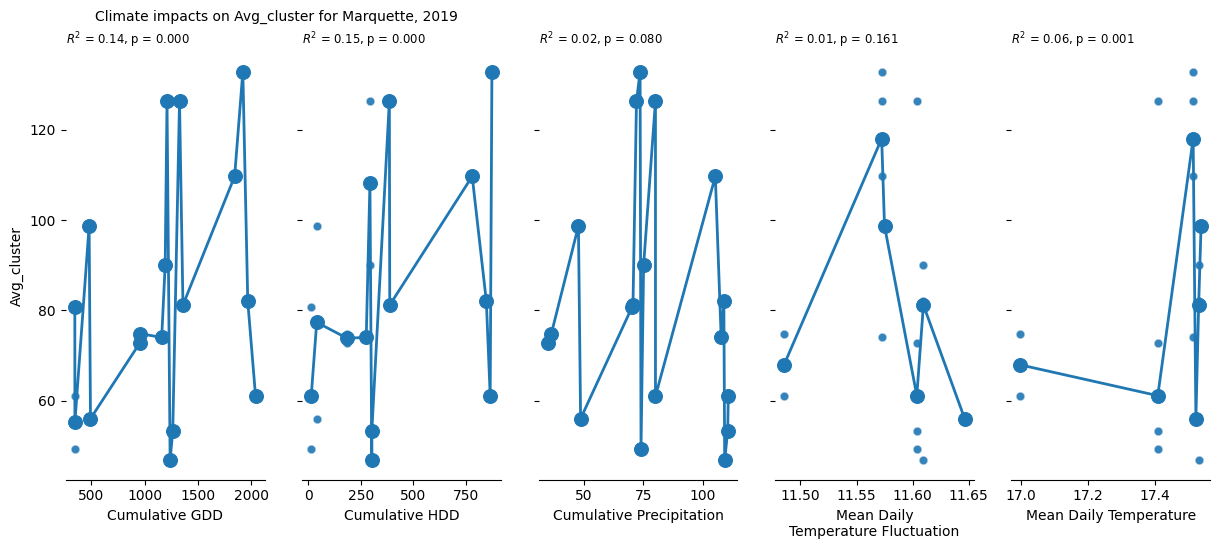

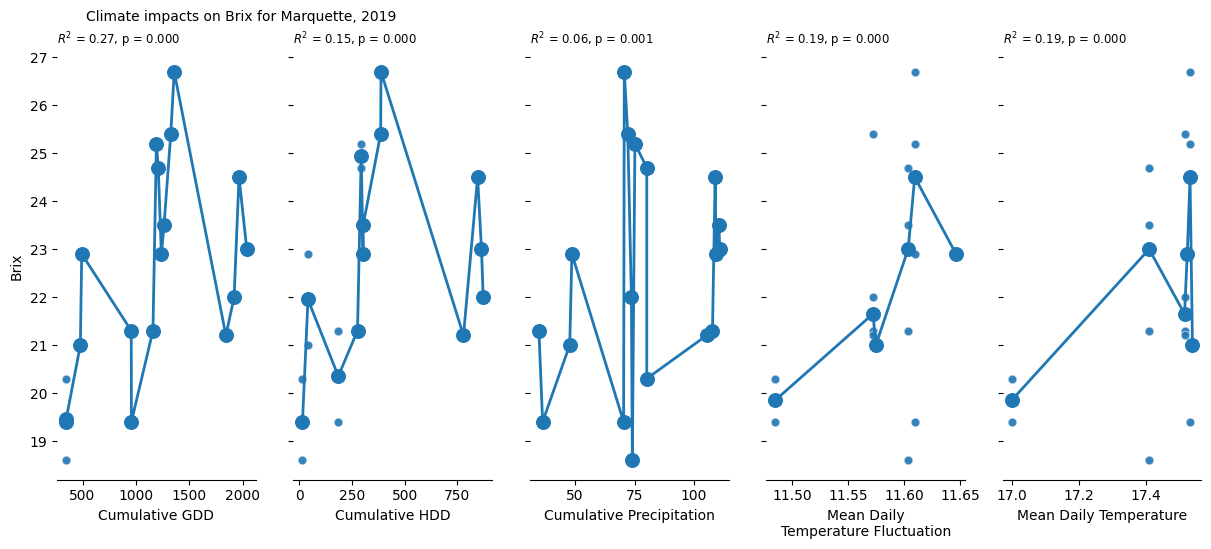

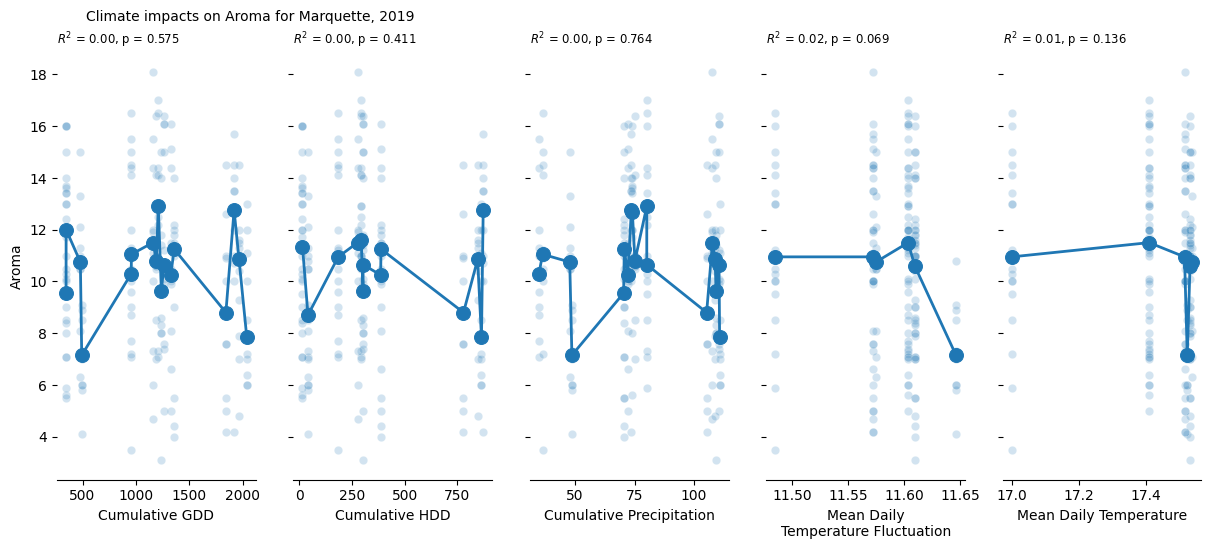

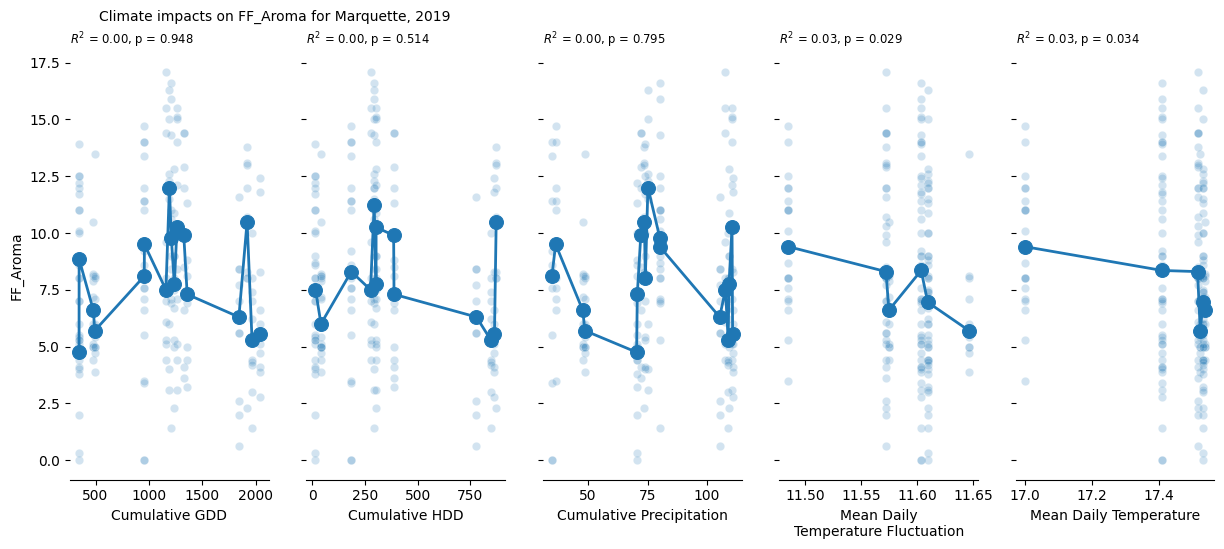

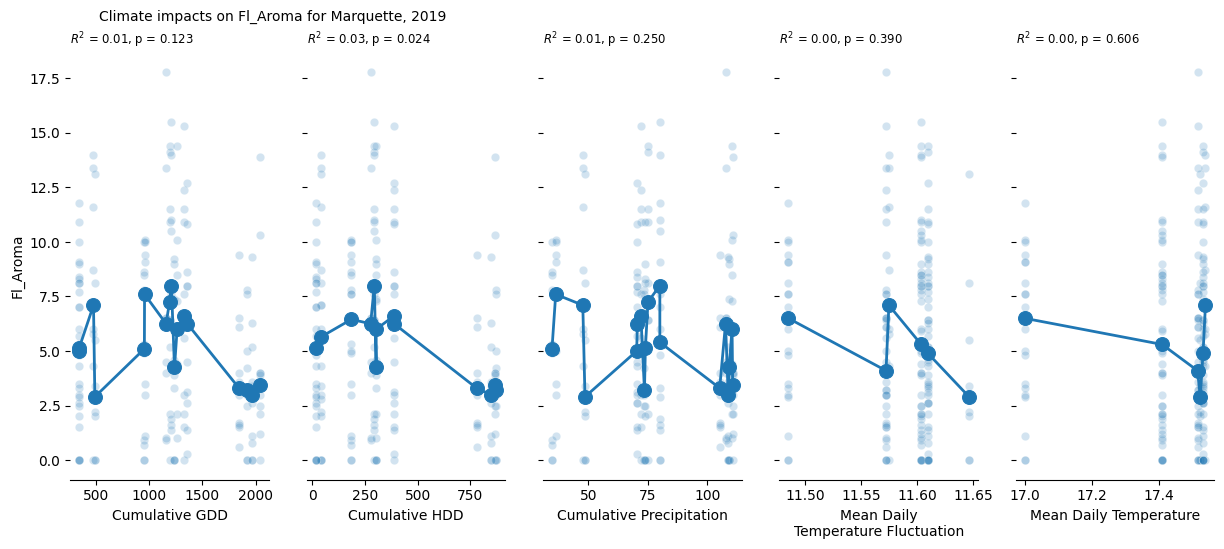

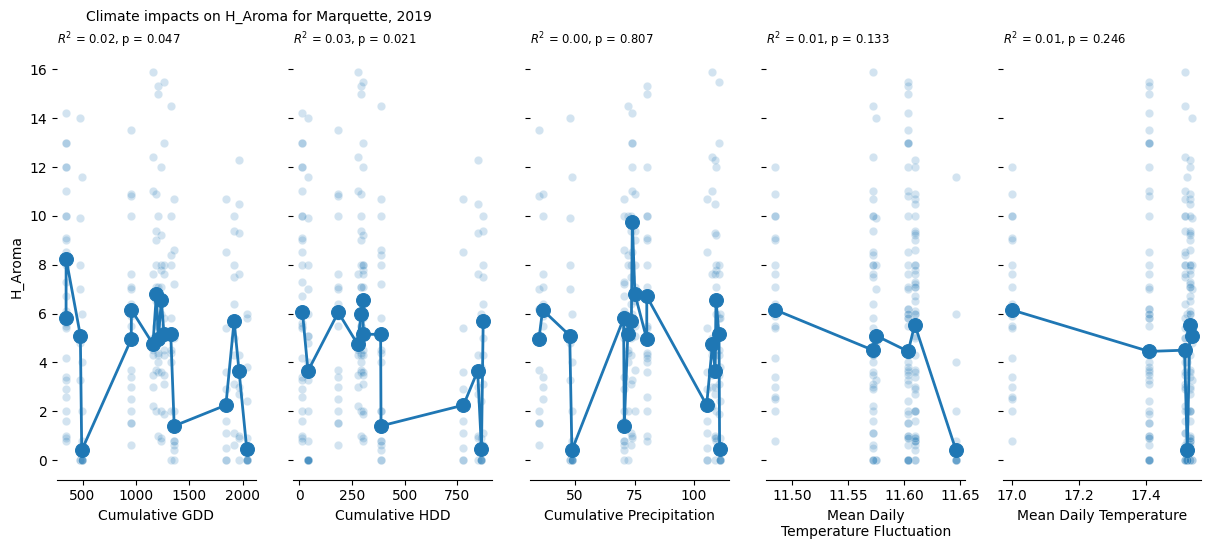

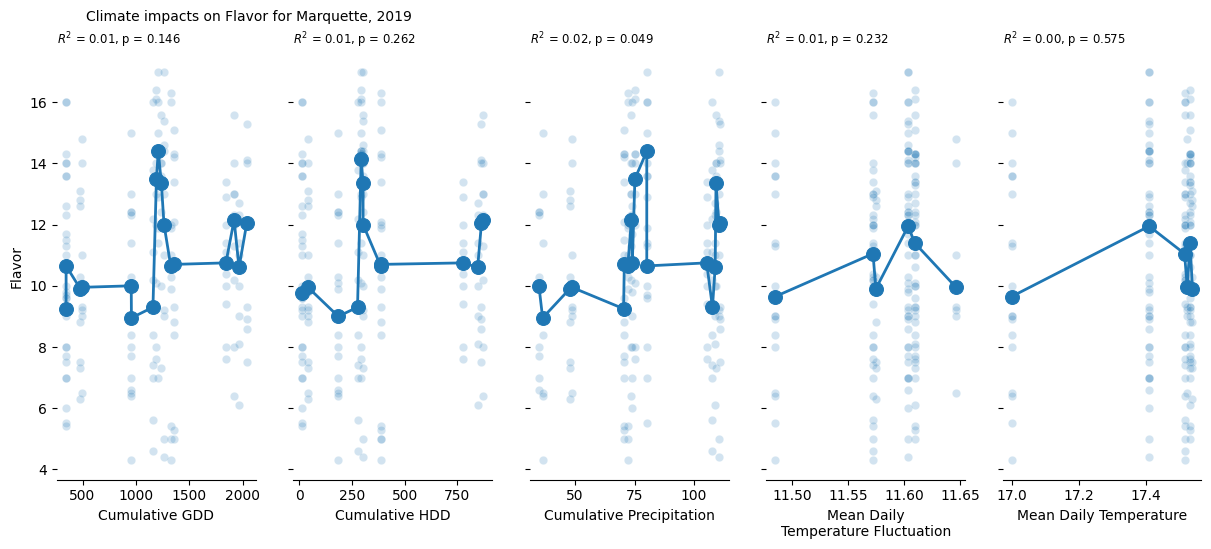

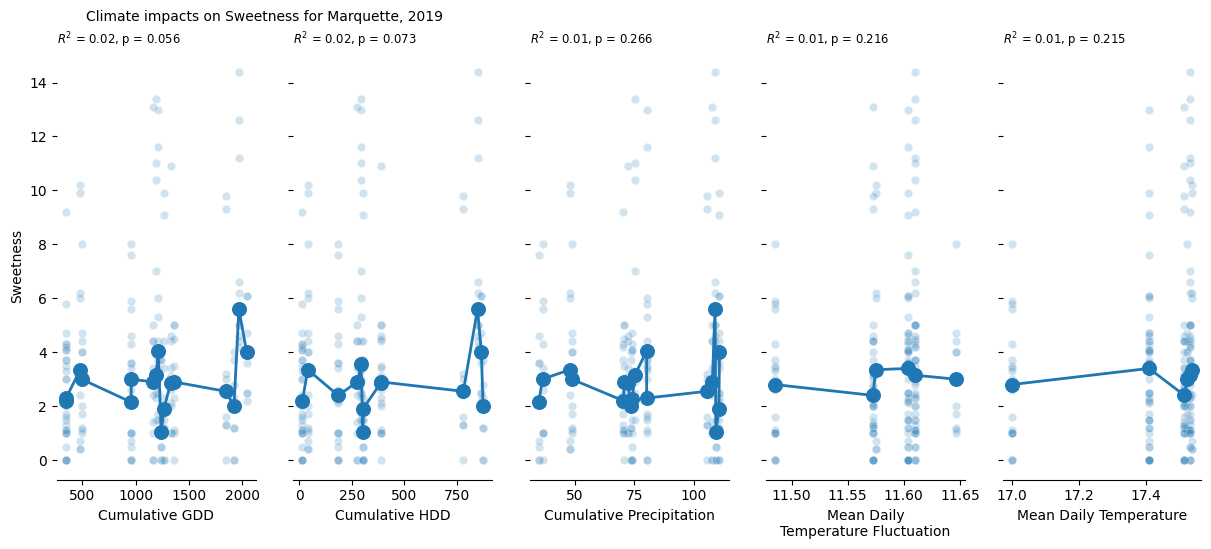

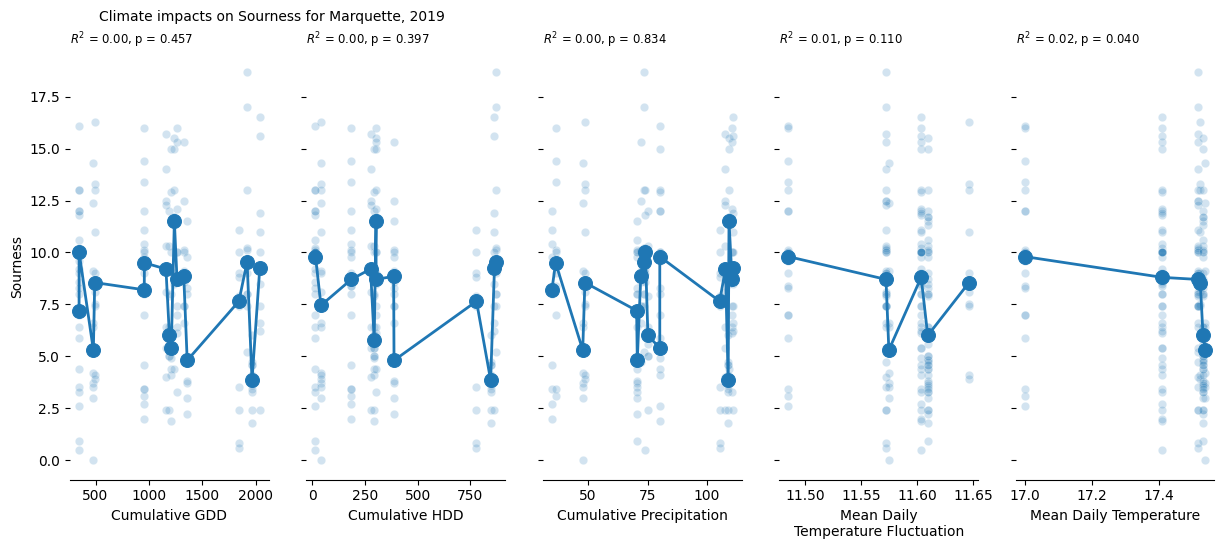

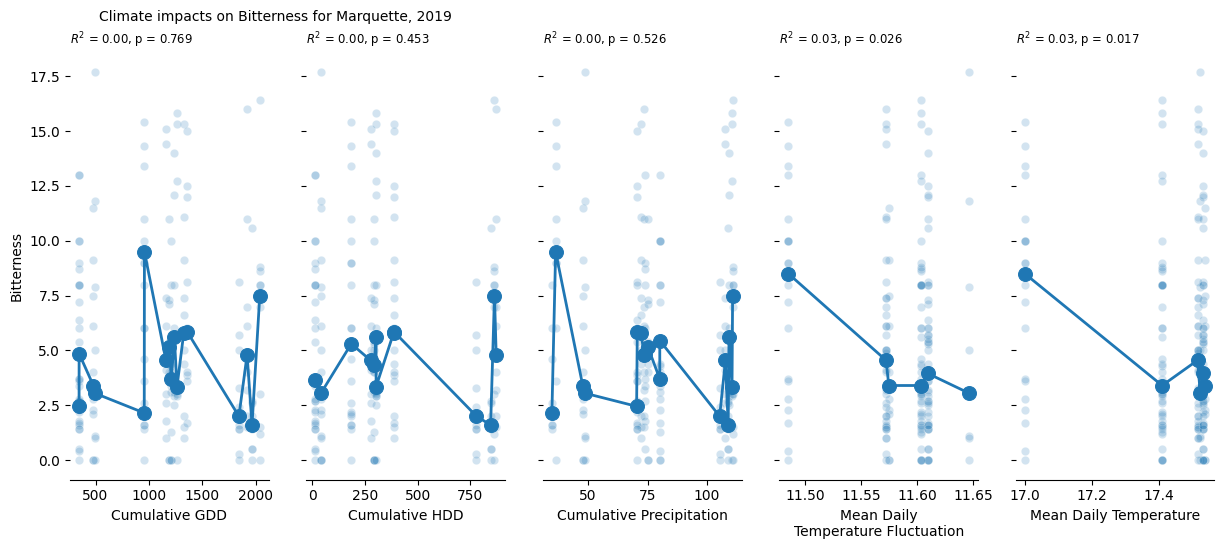

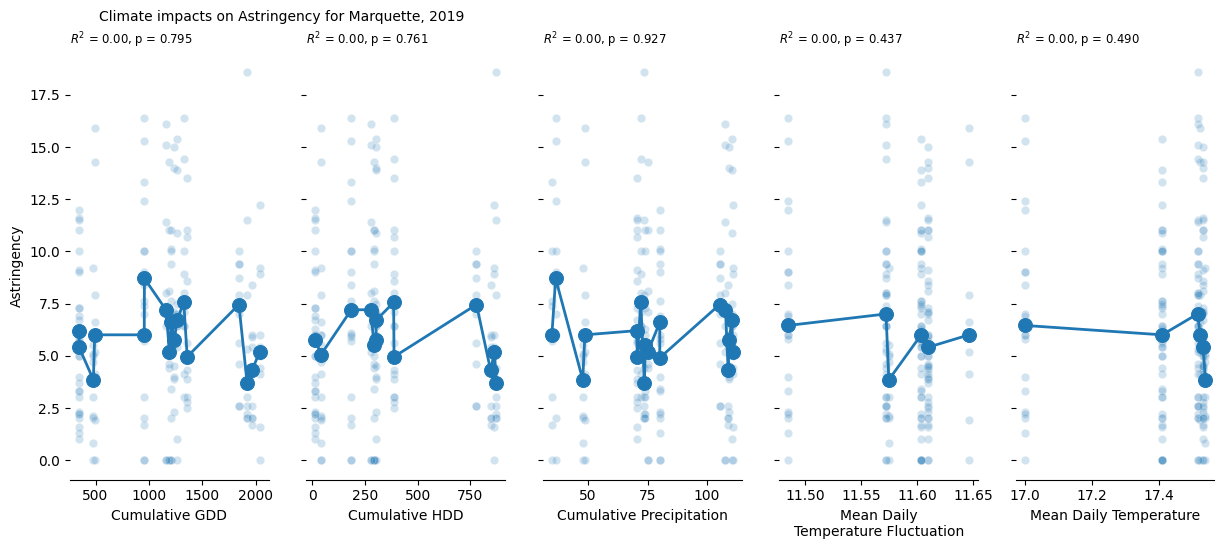

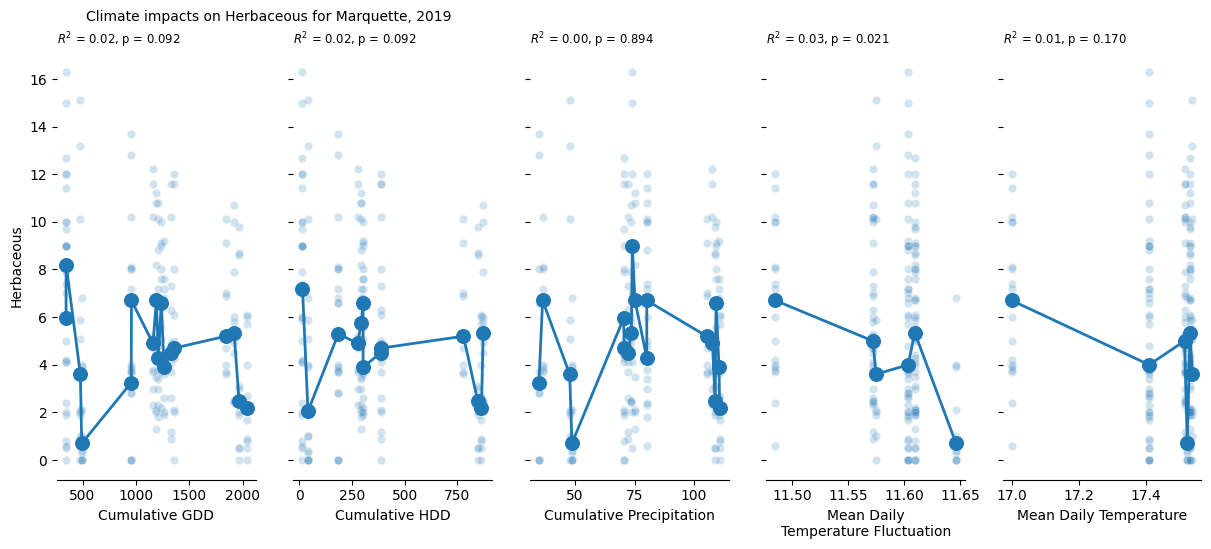

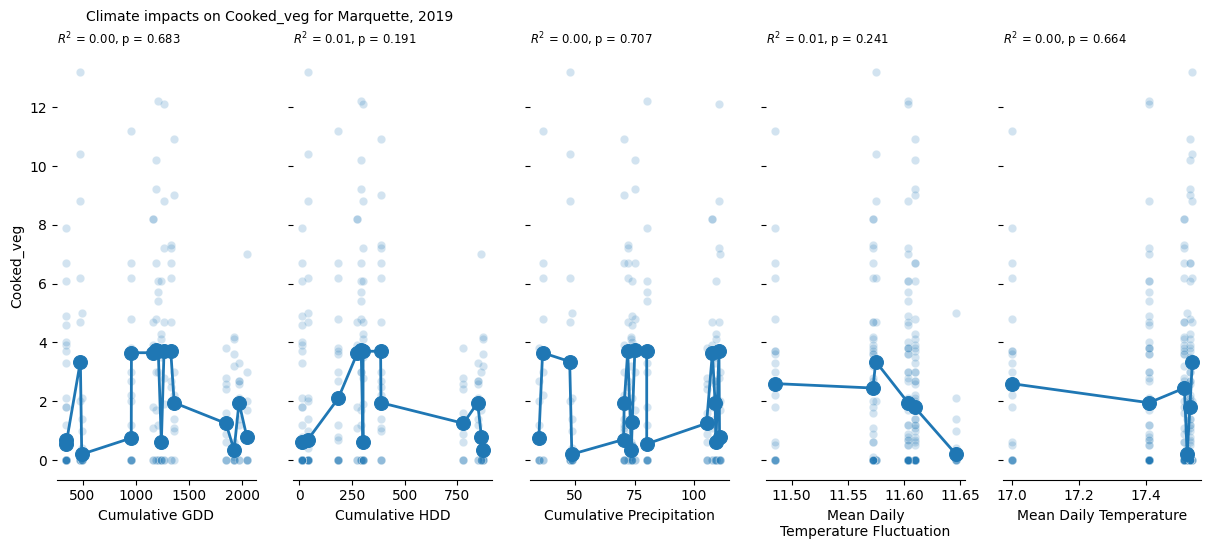

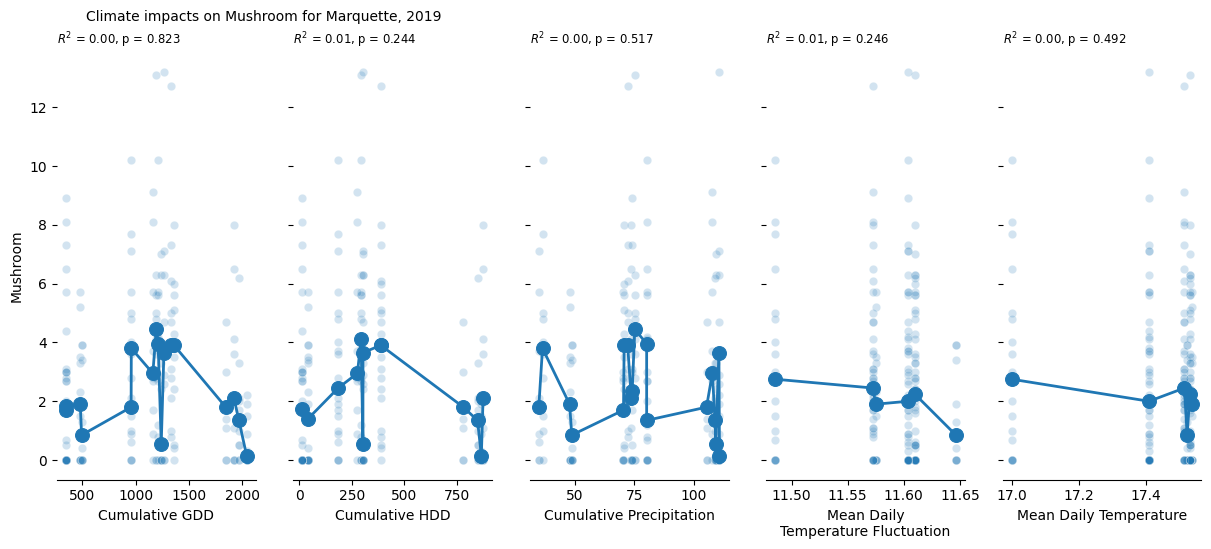

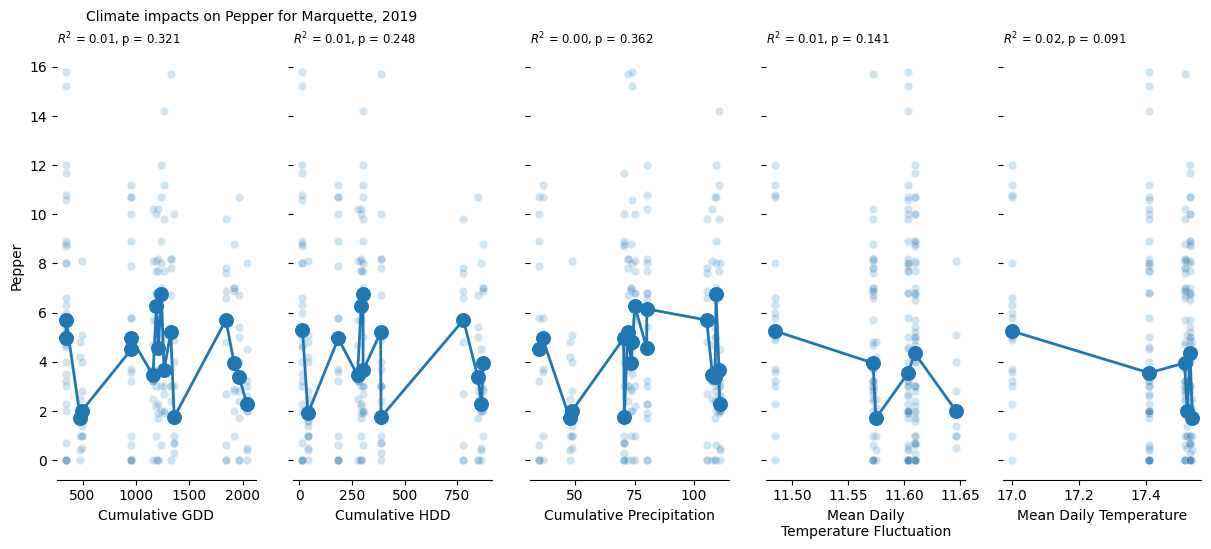

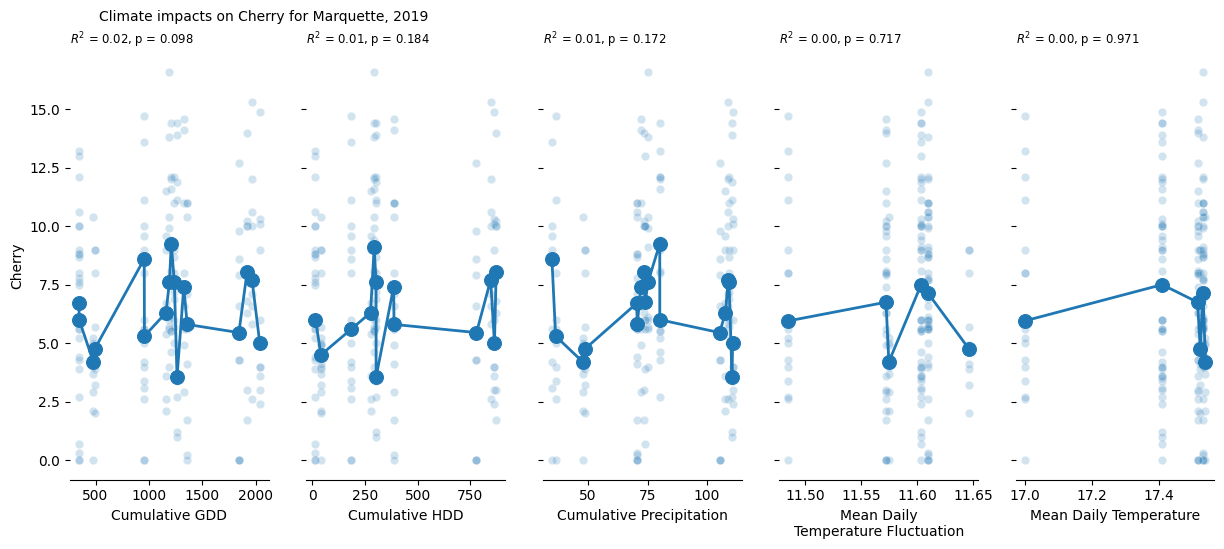

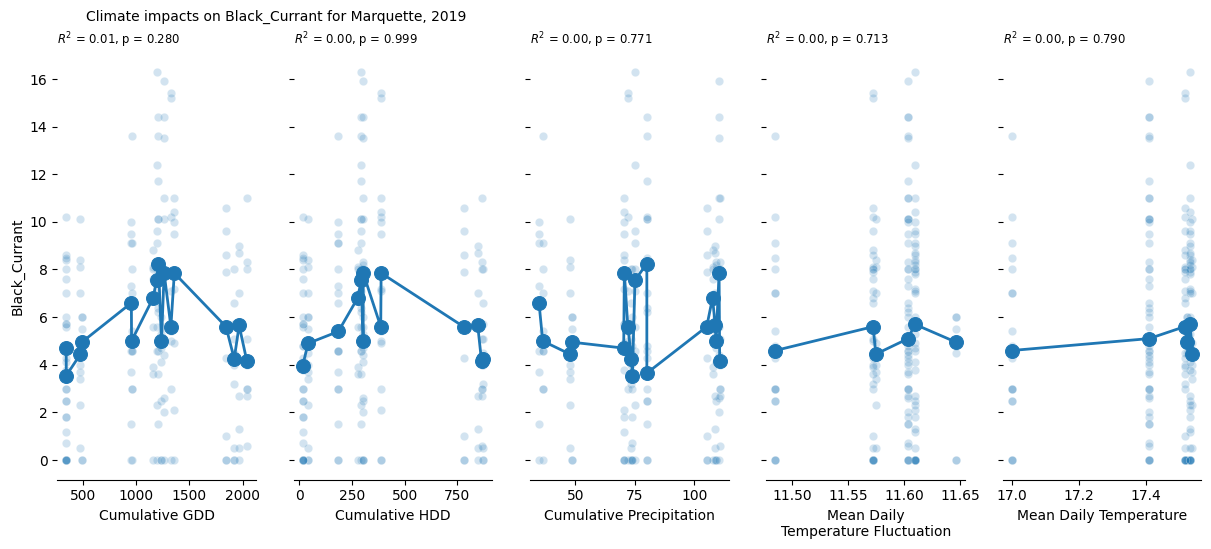

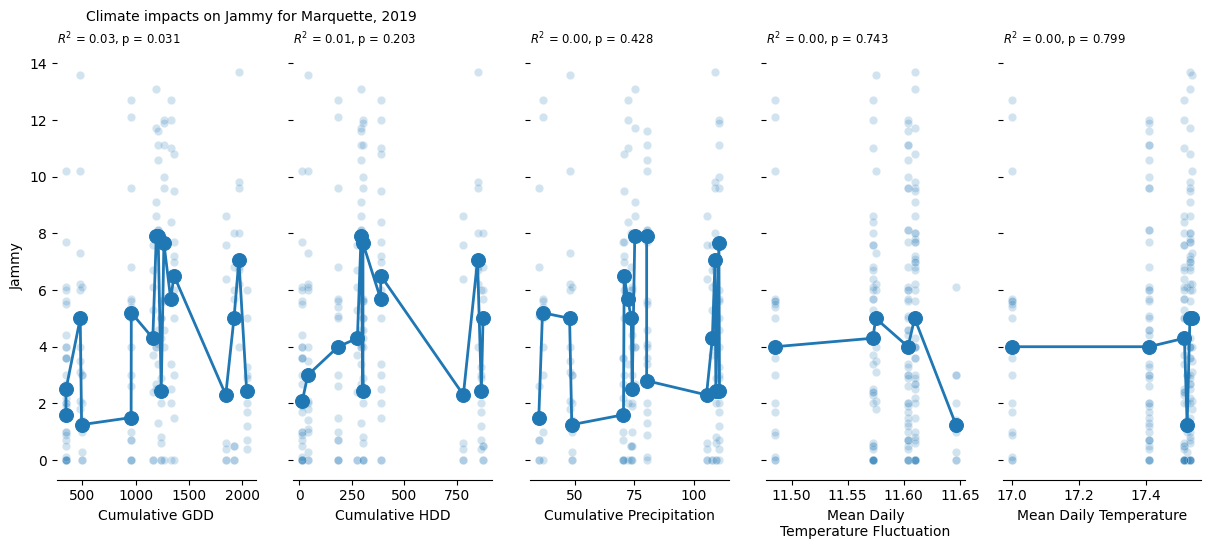

In [26]:
#Axis labels
labels = ['Cumulative GDD', 'Cumulative HDD', 'Cumulative Precipitation', 'Mean Daily\nTemperature Fluctuation', 'Mean Daily Temperature']
vars_of_interest = ['Avg_cluster', 'Brix', 'Aroma', 'FF_Aroma', 'Fl_Aroma', 'H_Aroma', 'Flavor', 'Sweetness', 'Sourness', 'Bitterness',
       'Astringency', 'Herbaceous', 'Cooked_veg', 'Mushroom',
       'Pepper', 'Cherry', 'Black_Currant', 'Jammy']
x_vars = ["index_GDD_cum", "index_HDD_cum", "value_precip_cm", "value_meanDiurnal_C", "value_meanTemp_C"]
#categorical ones: 'Alcohol', 'Pleasing', 'Like', 'Ripeness'

for variable in vars_of_interest:
    #Correlation between Climate and Overall Flavor
    g = sns.PairGrid(all_data, y_vars=variable, 
                    x_vars=x_vars,
                    height=5, aspect=.5)

    # Draw a seaborn pointplot onto each Axes
    g.map(sns.scatterplot, alpha = 0.2)
    g.map(sns.lineplot, marker = 'o', markersize = 10, linewidth = 2, markeredgecolor = None,
        estimator = 'median', errorbar = None)

    for i, row in enumerate(g.axes):
        for j, ax in enumerate(row):
            if ax is not None:
                ax.set_xlabel(labels[j], fontsize = 10)

                #linear regression for significance testing
                p_value, r_value = calc_corr(x = all_data[x_vars[j]], y = all_data[variable], return_p = True)
                ax.set_title(r'$R^2$ = %.2f, p = %.3f' % (r_value, p_value), loc = 'left', size = 'small')

    g.figure.suptitle('Climate impacts on ' + variable + ' for Marquette, 2019', horizontalalignment = 'left', x = 0.08, y = 1.05, size = 10)
    sns.despine(fig=g.fig, left=True)
    #g.add_legend(title = ' ', bbox_to_anchor = (0.18,1.1))

    #save
    g.savefig('./figures/climate impact exploration/climateImpacts_' + variable + '.pdf', bbox_inches = 'tight')
    g.savefig('./figures/climate impact exploration/climateImpacts_' + variable + '.png', dpi = 300, bbox_inches = 'tight')
